# Preliminaries

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load needed python resources
from datascience import *
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
matplotlib.use('Agg')
%matplotlib inline
import math
from scipy import stats
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

In [ ]:
pwd

'/content/drive/My Drive/data'

In [ ]:
cd /content/drive/MyDrive/data

/content/drive/MyDrive/data


In [ ]:
ls

airlines.csv  airports.csv  flights.csv


# Problem 1

Repeat the steps in Lab 6 to create the giant Table object, called flights, with 5.8 million rows of
data. After this is done, we only need the column called AIR_TIME so reduce the flights object to just
that column.

In [ ]:
flights = Table.read_table('flights.csv')

/usr/local/lib/python3.11/dist-packages/datascience/tables.py:163: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pandas.read_csv(filepath_or_buffer, *args, **vargs)


In [ ]:
flights = flights.select('AIR_TIME')

# Problem 2

Delete the AIR_TIME values that equal nan (which means "not a number") using the code listed
below. Then, use the num_rows method to find the number of observations in the airtimes dataset
after removing the nan’s.

In [ ]:
# Create a np.array from the AIR_TIME column
airtimes = np.array(flights.column('AIR_TIME'))

# Get rid of all nan entries using np.isnan
airtimes = airtimes[~np.isnan(airtimes)]

# Put the modified array back into a Table
airtimes = Table().with_column('AirTime', airtimes)

# Find the number of observations after removing NaNs
num_observations = airtimes.num_rows
num_observations


5714008

# Problem 3

Then, create a histogram of the data. Your histogram should show that the dataset is skewed
toward larger times. Verify directly that the mean is larger than the median for this right skewed
distribution.

In [ ]:
# Calculate the mean and median
mean_airtime = np.mean(airtimes.column('AirTime'))
median_airtime = np.median(airtimes.column('AirTime'))
mean_airtime, median_airtime

(113.51162809012519, 94.0)

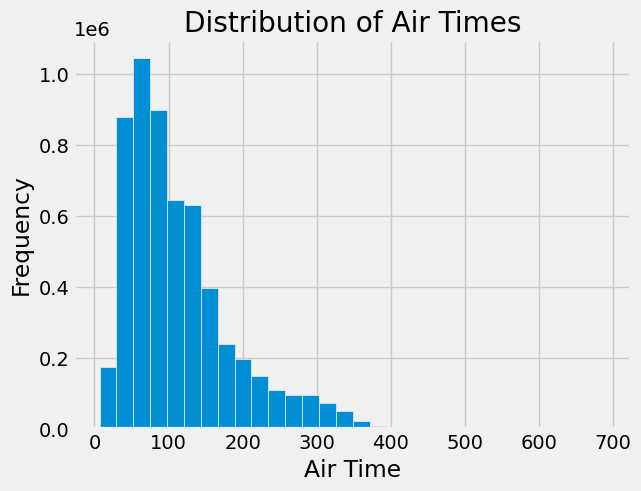

In [ ]:
# Create a histogram of the airtimes
plt.hist(airtimes.column('AirTime'), bins=30)
plt.xlabel('Air Time')
plt.ylabel('Frequency')
plt.title('Distribution of Air Times')
plt.show()

# Problem 4

Use the simulate_sample_mean function from Section 14.5 to generate a histogram of sample means
from 10,000 samples of size 𝑛 = 1 from AIR_TIME. What is the shape of the histogram? Is this what
you expected, and why? Explain your answers in a text box.

In [ ]:
"""Empirical distribution of random sample means"""

def simulate_sample_mean(table, label, sample_size, repetitions):

    means = make_array()

    for i in range(repetitions):
        new_sample = table.sample(sample_size)
        new_sample_mean = np.mean(new_sample.column(label))
        means = np.append(means, new_sample_mean)

    sample_means = Table().with_column('Sample Means', means)

    # Display empirical histogram and print all relevant quantities
    sample_means.hist(bins=20)
    plt.xlabel('Sample Means')
    plt.title('Sample Size ' + str(sample_size))
    print("Sample size: ", sample_size)
    print("Population mean:", np.mean(table.column(label)))
    print("Average of sample means: ", np.mean(means))
    print("Population SD:", np.std(table.column(label)))
    print("SD of sample means:", np.std(means))

Sample size:  1
Population mean: 113.51162809
Average of sample means:  113.6422
Population SD: 72.2308152998
SD of sample means: 71.4022841313


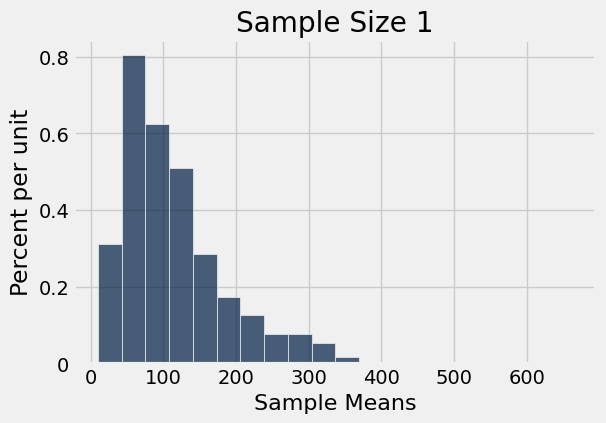

In [ ]:
simulate_sample_mean(airtimes, 'AirTime', 1, 10000)

- This histogram retains the right-skewed shape of the population distribution. Since each sample consists of just one observation, there is no averaging effect to smooth out variability. This matches expectations because small samples closely resemble the original data.

 ‎

‎

‎

‎

‎

‎

‎

‎

‎

‎

‎

# Problem 5

Now repeat step 4, including answering the questions, using 𝑛 = 5 and 𝑛 = 100

Sample size:  5
Population mean: 113.51162809
Average of sample means:  113.6422
Population SD: 72.2308152998
SD of sample means: 32.1176376958


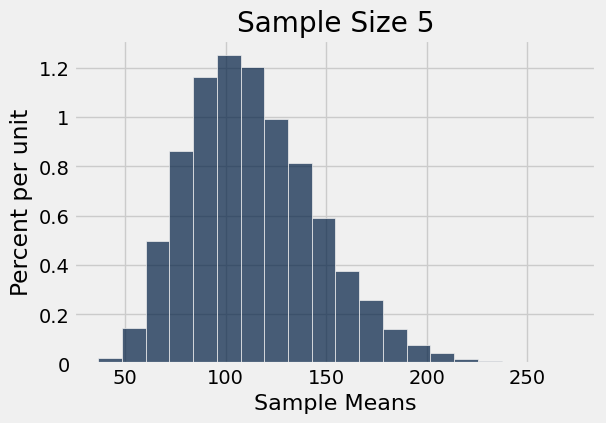

In [ ]:
simulate_sample_mean(airtimes, 'AirTime', 5, 10000)

Sample size:  100
Population mean: 113.51162809
Average of sample means:  113.561833
Population SD: 72.2308152998
SD of sample means: 7.21191378416


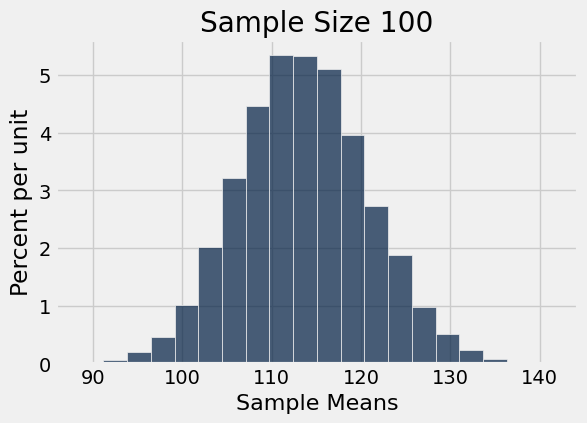

In [ ]:
simulate_sample_mean(airtimes, 'AirTime', 100, 10000)

- Sample sizes 5 and 100 get more symmetric as they begin to resemble a normal distribution. The Central Limit Theorem predicts this behavior as increasing sample sizes average out extreme values. Larger sample sizes (e.g., 100) would make the distribution even more normal.

# Problem 6

In this case, we are sampling from a population that is entirely known to us. Therefore, we can
calculate the exact value of the population standard deviation. Find this SD and display it in your
report. Then calculate the SD of sample means from steps 4 and 5 using the information in Section
14.5.2. Summarize these values side by side next to the SDs of sample means that were measured
in the simulations in steps 4 and 5. (The values should be very close. This comparison is similar to
the SD comparison in Section 14.5.1. You can use code from 14.5.1 for creating the table, but you
should remove unnecessary pieces. Your table should only show 3 rows: n = 1, n = 5, and n =
100.)

In [ ]:
pop_sd = np.std(airtimes.column('AirTime'))
pop_sd

72.230815299781042

In [ ]:
repetitions = 10000
sample_sizes = (1, 5, 100)

sd_means = make_array()

for n in sample_sizes:
    means = make_array()
    for i in np.arange(repetitions):
        means = np.append(means, np.mean(airtimes.sample(n).column('AirTime')))
    sd_means = np.append(sd_means, np.std(means))

sd_comparison = Table().with_columns(
    'Sample Size n', sample_sizes,
    'SD of 3 Sample Means', sd_means,
    'pop_sd/sqrt(n)', pop_sd/np.sqrt(sample_sizes)
)

In [ ]:
sd_comparison

Sample Size n,SD of 3 Sample Means,pop_sd/sqrt(n)
1,72.5882,72.2308
5,32.2093,32.3026
100,7.24201,7.22308
